In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import random
import os
os.environ["TORCH_DYNAMO_DISABLE"] = "1"

import torch
# ... rest of your imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# --- 1. SET RANDOM SEED FOR REPRODUCIBILITY ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Ensure deterministic behavior on CuDNN (GPU backend)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Random Seed Locked: 42")
print(f"🚀 Computation Device: {device}")

✅ Random Seed Locked: 42
🚀 Computation Device: cuda


In [2]:
# --- 2. HYPERPARAMETERS ---
MAX_LEN = 200        # Max length of URL
BATCH_SIZE = 128     # Batch size for 4050
EMBED_DIM = 32       # Character embedding size
CNN_FILTERS = 32     # Reduced filters (per kernel size)
LSTM_UNITS = 64      # LSTM Hidden size
EPOCHS = 10          # Number of training runs
LEARNING_RATE = 0.001

# --- 3. VOCAB & TOKENIZER ---
# All printable characters we care about
VOCAB = "abcdefghijklmnopqrstuvwxyz0123456789-._~:/?#[]@!$&'()*+,;="
char_to_int = {ch: i + 1 for i, ch in enumerate(VOCAB)} # Start index at 1 (0 is padding)
VOCAB_SIZE = len(char_to_int) + 1

def tokenizer(url):
    """Converts a URL string into a list of integers."""
    url = str(url).lower().strip()
    encoded = [char_to_int.get(c, 0) for c in url[:MAX_LEN]]
    # Padding: Add 0s to reach MAX_LEN
    encoded += [0] * (MAX_LEN - len(encoded))
    return encoded

# --- 4. CUSTOM DATASET CLASS ---
class PhishDataset(Dataset):
    def __init__(self, df):
        self.urls = df['url'].values
        self.labels = df['label_num'].values
        
    def __len__(self):
        return len(self.urls)
    
    def __getitem__(self, idx):
        # Tokenize URL
        x = tokenizer(self.urls[idx])
        y = self.labels[idx]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.float32)

# --- 5. LOAD & SPLIT DATA ---
print("📂 Loading data...")
# Read CSV
df = pd.read_csv("train_slim.csv")

# Clean Labels: Map text to numbers
label_map = {'benign': 0.0, 'phish': 1.0}
df['label'] = df['label'].astype(str).str.lower().str.strip()
df['label_num'] = df['label'].map(label_map)

# Drop junk rows
df = df.dropna(subset=['label_num'])
print(f"📊 Total Samples: {len(df)}")

# Train / Validation Split (80% Train, 20% Val)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label_num'])

# Create DataLoaders
train_dataset = PhishDataset(train_df)
val_dataset = PhishDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Data Ready. Train: {len(train_df)}, Val: {len(val_df)}")

📂 Loading data...
📊 Total Samples: 113564
✅ Data Ready. Train: 90851, Val: 22713


In [3]:
class MultiScalePhishNet(nn.Module):
    def __init__(self, vocab_size, embed_dim, filters, kernel_sizes, lstm_units):
        super(MultiScalePhishNet, self).__init__()
        
        # Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # Parallel CNN Layers (ModuleList allows us to have a list of layers)
        # We use padding to keep the sequence length the same for concatenation
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, 
                      out_channels=filters, 
                      kernel_size=k, 
                      padding=k//2) # Padding logic to keep length roughly same
            for k in kernel_sizes
        ])
        
        self.leaky_relu = nn.LeakyReLU(negative_slope=0.01)
        self.dropout = nn.Dropout(0.3) # Added dropout for regularization
        
        # BiLSTM Layer
        # Input size = filters * number of kernels (since we verify concatenation)
        self.lstm = nn.LSTM(input_size=filters * len(kernel_sizes), 
                            hidden_size=lstm_units, 
                            bidirectional=True, 
                            batch_first=True)
        
        # Fully Connected Layer
        self.fc = nn.Linear(lstm_units * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # 1. Embed: (Batch, Seq_Len, Embed_Dim)
        x = self.embedding(x)
        
        # 2. Transpose for CNN: (Batch, Embed_Dim, Seq_Len)
        x = x.transpose(1, 2)
        
        # 3. Apply Parallel CNNs
        # We trim outputs to match the shortest length to ensure safe concatenation
        conv_outputs = []
        for conv in self.convs:
            conv_out = self.leaky_relu(conv(x))
            conv_outputs.append(conv_out)
            
        # Ensure all have same length (min length) before stacking
        min_len = min([out.shape[2] for out in conv_outputs])
        conv_outputs = [out[:, :, :min_len] for out in conv_outputs]
        
        # Concatenate along channel dimension: (Batch, Total_Filters, Seq_Len)
        x = torch.cat(conv_outputs, dim=1)
        
        # 4. Transpose for LSTM: (Batch, Seq_Len, Total_Filters)
        x = x.transpose(1, 2)
        x = self.dropout(x)
        
        # 5. BiLSTM
        _, (hidden, _) = self.lstm(x)
        
        # Concatenate forward and backward hidden states
        x = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        # 6. Classification
        x = self.fc(x)
        return self.sigmoid(x)

# Initialize Model
model = MultiScalePhishNet(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    filters=CNN_FILTERS,
    kernel_sizes=[2, 3, 4, 5],
    lstm_units=LSTM_UNITS
).to(device)

print(model)

MultiScalePhishNet(
  (embedding): Embedding(59, 32, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(32, 32, kernel_size=(2,), stride=(1,), padding=(1,))
    (1): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (2): Conv1d(32, 32, kernel_size=(4,), stride=(1,), padding=(2,))
    (3): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  )
  (leaky_relu): LeakyReLU(negative_slope=0.01)
  (dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(128, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [4]:
# Setup Loss and Optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Track metrics for plotting
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print(f"🚀 Starting Training for {EPOCHS} Epochs...")

for epoch in range(EPOCHS):
    # --- TRAIN STEP ---
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader)
    
    # --- VALIDATION STEP ---
    model.eval()
    val_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device).unsqueeze(1)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            
            # Calculate accuracy
            preds = (outputs > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = accuracy_score(all_labels, all_preds)
    
    # Save Metrics
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_accuracy)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_accuracy*100:.2f}%")

# Save the deterministic model
torch.save(model.state_dict(), "phish_model_v2_deterministic.pth")
print("\n💾 Model Saved: phish_model_v2_deterministic.pth")

🚀 Starting Training for 10 Epochs...
Epoch [1/10] Train Loss: 0.2362 | Val Loss: 0.1215 | Val Acc: 95.34%
Epoch [2/10] Train Loss: 0.1108 | Val Loss: 0.0943 | Val Acc: 96.29%
Epoch [3/10] Train Loss: 0.0921 | Val Loss: 0.0819 | Val Acc: 97.00%
Epoch [4/10] Train Loss: 0.0799 | Val Loss: 0.0753 | Val Acc: 97.27%
Epoch [5/10] Train Loss: 0.0732 | Val Loss: 0.0744 | Val Acc: 97.27%
Epoch [6/10] Train Loss: 0.0682 | Val Loss: 0.0696 | Val Acc: 97.44%
Epoch [7/10] Train Loss: 0.0635 | Val Loss: 0.0685 | Val Acc: 97.61%
Epoch [8/10] Train Loss: 0.0595 | Val Loss: 0.0639 | Val Acc: 97.74%
Epoch [9/10] Train Loss: 0.0565 | Val Loss: 0.0669 | Val Acc: 97.68%
Epoch [10/10] Train Loss: 0.0529 | Val Loss: 0.0662 | Val Acc: 97.78%

💾 Model Saved: phish_model_v2_deterministic.pth


In [5]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"Is GPU available? {torch.cuda.is_available()}")
# This line is where your error used to happen:
print(f"Device Index check: {torch.cuda.current_device()}")

PyTorch Version: 2.6.0+cu124
Is GPU available? True
Device Index check: 0


✅ Model loaded successfully!
🧪 Evaluating on validation set...

📊 Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      0.98      0.98     15400
    Phishing       0.97      0.96      0.97      7313

    accuracy                           0.98     22713
   macro avg       0.97      0.97      0.97     22713
weighted avg       0.98      0.98      0.98     22713



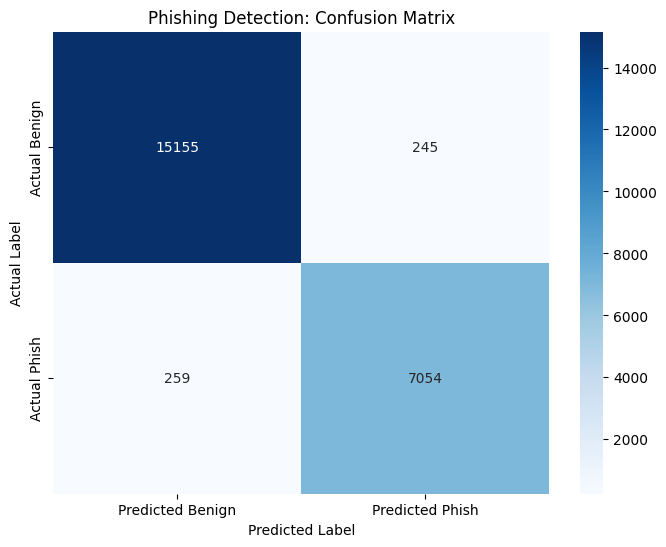

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --- 1. CONFIGURATION (Must match your Training code exactly) ---
VOCAB_SIZE = len(char_to_int) + 1  # 57 based on your VOCAB string
EMBED_DIM = 32
CNN_FILTERS = 32      # Match the '32' from your error message
LSTM_UNITS = 64
KERNEL_SIZES = [2, 3, 4, 5]

# --- 2. INITIALIZE & LOAD ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiScalePhishNet(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    filters=CNN_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    lstm_units=LSTM_UNITS
).to(device)

# Load the saved file
model.load_state_dict(torch.load("phish_model_v2_deterministic.pth"))
model.eval()
print("✅ Model loaded successfully!")

# --- 3. EVALUATION LOOP ---
all_preds = []
all_labels = []

print("🧪 Evaluating on validation set...")
with torch.no_grad():
    for batch_x, batch_y in val_loader:
        batch_x = batch_x.to(device)
        outputs = model(batch_x)
        
        # Binary threshold at 0.5
        preds = (outputs > 0.5).float().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch_y.numpy())

all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

# --- 4. PRINT METRICS ---
print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Benign', 'Phishing']))

# --- 5. PLOT CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Benign', 'Predicted Phish'],
            yticklabels=['Actual Benign', 'Actual Phish'])
plt.title('Phishing Detection: Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()